In [11]:
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml

In [12]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

In [13]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [14]:
question_answer_dict = defaultdict(list)

cnt = 0

for publisher, publisher_results in processed_data.items():
    for journal, journal_results in publisher_results.items():
        cnt += 1
        for question, answer in journal_results.items():
            
            # Use the correct answer
            try:
                if "Code sharing encouraged" in answer.correct_answer.text:
                    print(answer.correct_answer.text, publisher, journal)
                #print(f"Question: {question} {publisher.keys()}")
            except:
                pass
            question_answer_dict[question].append(answer.correct_answer.text)

# Count the number of times each answer was given
count_dict = {
    question: pd.Series(answers).value_counts()
    for question, answers in question_answer_dict.items()
}
count_publisher = defaultdict(int)
for publisher, _ in processed_data.items():
    for journal_results in _.keys():
#        print(f"{publisher}: {journal_results}")
        count_publisher[publisher]+=1

print("number of journals", cnt)


Code sharing encouraged but optional. ACS inorganic_chemistry
Code sharing encouraged but optional. ACS journal_of_medicinal_chemistry
Code sharing encouraged but optional. ACS the_journal_of_physical_chemistry_c
Code sharing encouraged but optional. APS physical_review_d
Code sharing encouraged but optional. APS physical_review_e
Code sharing encouraged but optional. APS physical_review_letters
Code sharing encouraged but optional. APS physical_review_c
Code sharing encouraged but optional. APS physical_review_materials
Code sharing encouraged but optional. APS physical_review_x
Code sharing encouraged but optional. APS physical_review_b
Code sharing encouraged but optional. APS prx_quantum
Code sharing encouraged but optional. APS physical_review_a
Code sharing encouraged but optional. APS physical_review_applied
Code sharing encouraged but optional. APS physical_review_research
Code sharing encouraged but optional. Elsevier optical_materials
Code sharing encouraged but optional. Els

In [15]:
count_dict.keys()

dict_keys(['rdp_exist', 'data_sharing', 'data_fair', 'data_availability', 'data_citability', 'data_timing', 'data_sharing_method', 'data_licenses', 'data_referee', 'data_recommended', 'data_required', 'code_required', 'code_reproducibility', 'code_versioning', 'code_quality', 'code_autotest', 'code_docs', 'code_linting', 'code_development'])

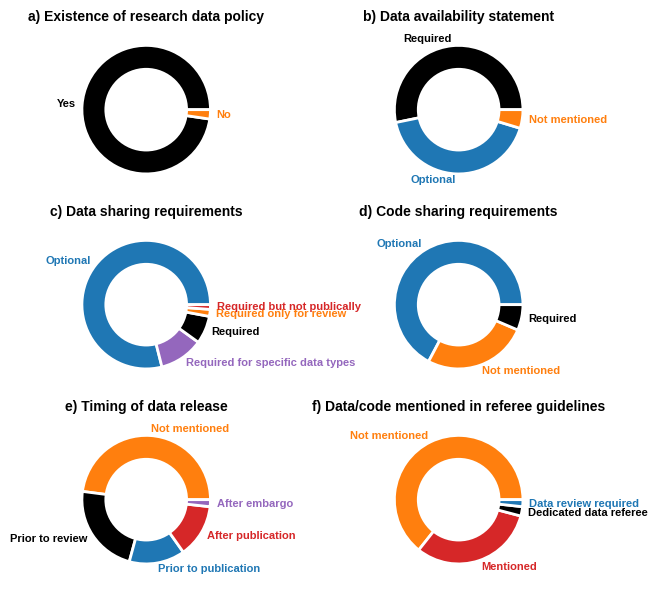

In [16]:
import seaborn as sns 
import textwrap


fig = plt.figure(figsize=(7, 6))

title_dict = {"rdp_exist" : "a) Existence of research data policy",
              "data_availability" : "b) Data availability statement",
              "data_sharing" : "c) Data sharing requirements",
              "code_required" : "d) Code sharing requirements",
              "data_timing" : "e) Timing of data release",
              "data_referee" : "f) Data/code mentioned in referee guidelines",
}

label_dict = {"research data policy (rdp) exists." : "Yes",
              "research data policy (rdp) does not exists." : "No",
              "required according to the rdp." : "Required",
              "mentioned in the rdp but optional." : "Optional",
              "not mentioned in the rdp." : "Not mentioned",
              "data sharing encouraged but optional." : "Optional",
              "public data sharing required only for specific types of data." : "Required for specific data types",
              "data sharing required but not publicly (e.g. available upon request is allowed)." : "Required but not publically",
              "data sharing only with editors and referees (no public sharing)" : "Required only for review",
              "public data sharing of all data required." : "Required",
              "code sharing encouraged but optional." : "Optional",
              "code sharing not mentioned." : "Not mentioned",
              "code sharing required." : "Required",
              "timing of data availability not adressed in rdp." : "Not mentioned",
              "required data must be available prior to review process." : "Prior to review",
              "required data must be available prior to official publication." : "Prior to publication",
              "required data must be available after official publication." : "After publication",
              "required data must be available after an embargo period." : "After embargo",
              "data sharing policy not mentioned in refereeing guidelines." : "Not mentioned",
              "data sharing policy mentioned in refereeing guidelines." : "Mentioned",
              "confirmation of shared data or code by referee required." : "Data review required",
              "additional data or code referee (referee that solely confirms that code and data are shared following the rdp)." : "Dedicated data referee",
}

color_1 = "k"
color_2 = "C0"
color_3 = "C3"
color_4 = "C4"
color_5 = "C1"

color_dict = {"research data policy (rdp) exists." : color_1,
              "research data policy (rdp) does not exists." : color_5,
              "required according to the rdp." : color_1,
              "mentioned in the rdp but optional." : color_2,
              "not mentioned in the rdp." : color_5,
              "data sharing encouraged but optional." : color_2,
              "public data sharing required only for specific types of data." : color_4,
              "data sharing required but not publicly (e.g. available upon request is allowed)." : color_3,
              "data sharing only with editors and referees (no public sharing)" : color_5,
              "public data sharing of all data required." : color_1,
              "code sharing encouraged but optional." : color_2,
              "code sharing not mentioned." : color_5,
              "code sharing required." : color_1,
              "timing of data availability not adressed in rdp." : color_5,
              "required data must be available prior to review process." : color_1,
              "required data must be available prior to official publication." : color_2,
              "required data must be available after official publication." : color_3,
              "required data must be available after an embargo period." : color_4,
              "data sharing policy not mentioned in refereeing guidelines." : color_5,
              "data sharing policy mentioned in refereeing guidelines." : color_3,
              "confirmation of shared data or code by referee required." : color_2,
              "additional data or code referee (referee that solely confirms that code and data are shared following the rdp)." : color_1,
}

for ind, question in enumerate(["rdp_exist", "data_availability", "data_sharing", "code_required", "data_timing", "data_referee"]):
    plt.subplot(3, 2, ind+1)
    counts = count_dict[question]
    #counts = counts**0.95
    
    labels = []
    colors = []
    for key in list(counts.index):
        labels.append(label_dict[key.lower()])
        colors.append(color_dict[key.lower()])
        #print(f"Question: {key}, Answer: {label_dict[key.lower()]}, count: {counts[key]/sum(counts)*100}")

    #wedges, texts, autotexts = plt.pie(counts, labels=labels, autopct='%1.1f%%')
    
    wedges, texts = plt.pie(counts,
                            labels=labels,
                            colors=colors,
                            wedgeprops = {"edgecolor" : "white", 
                            'linewidth': 2, 
                            'antialiased': True},
                            #autopct='%1.1f%%',
                            )

    ### Add a hole in the pie  
    hole = plt.Circle((0, 0), 0.65, facecolor='white')
    plt.gcf().gca().add_artist(hole)

    for text, color in zip(texts, colors):
        text.set_color(color)
    
    plt.title(title_dict[question])
    plt.tight_layout()

fig.savefig("../../data/processed/data_sharing_requirements.pdf")

############################
rdp_exist
[0.97660819 0.02339181]
############################
data_availability
[0.53216374 0.42105263 0.04678363]
############################
data_sharing
[0.78947368 0.11111111 0.07017544 0.01754386 0.01169591]
############################
code_required
[0.67251462 0.26315789 0.06432749]
############################
data_timing
[0.47953216 0.22807018 0.14035088 0.13450292 0.01754386]
############################
data_referee
[0.64327485 0.31578947 0.02339181 0.01754386]


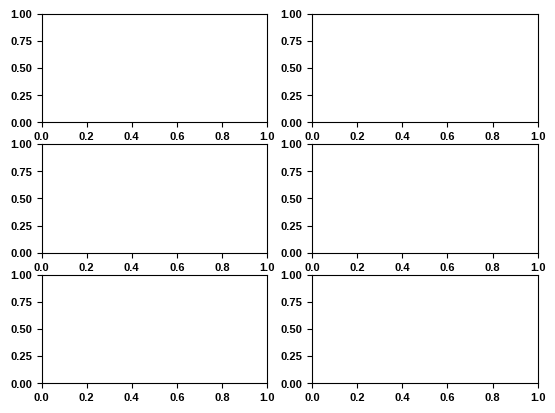

In [ ]:
for ind, question in enumerate(["rdp_exist", "data_availability", "data_sharing", "code_required", "data_timing", "data_referee"]):
    counts = count_dict[question]

    c_list = []
    for c in counts.values:
        c_list.append(c)

    c_list = np.array(c_list)

    print("############################")
    print(question)
    print(c_list / np.sum(c_list))